

---


# ***-->CreditCard Fraud Detection using Ensemble Machine Learning Techniques***

---



# Imports

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import FunctionTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

# Data Overview

In [3]:
df = pd.read_csv('creditcard.csv')
df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
130780,79430.0,1.247771,-0.254038,0.937926,-0.737644,-1.093941,-0.794367,-0.484058,-0.107391,1.623859,...,0.002684,0.321210,-0.051271,0.445236,0.544269,-0.690974,0.102176,0.038101,1.00,0
79096,57861.0,-0.745014,0.808457,1.852757,1.497271,-0.436193,1.363342,-0.370640,0.921098,0.051073,...,-0.218276,-0.285840,0.007121,-0.281397,-0.331125,-0.434745,0.108863,0.081181,19.99,0
207196,136562.0,-0.406432,-0.031807,1.279092,1.245104,0.139580,-0.437479,-0.376011,-0.044074,0.044570,...,-0.101170,-0.083531,0.110373,-0.059723,-1.392995,0.512184,0.196014,0.215843,35.86,0
151911,96482.0,1.522305,-2.008312,-0.817427,-0.479190,-1.274410,-0.159651,-0.813293,-0.174545,1.444617,...,0.431529,0.703706,-0.140595,0.557658,-0.320845,-0.163431,-0.083746,0.013103,356.30,0
23696,32872.0,-1.172778,-0.091209,2.879130,2.705712,0.601713,0.677548,-0.830258,0.445335,-0.667565,...,0.267670,0.668765,-0.184288,-0.525844,0.068837,0.422580,0.158085,-0.056920,26.85,0


In [4]:
print(f' Shape of the Dataset:-{df.shape}')

(284807, 31)

In [5]:
# Columns in the dataset:-
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
print(f'{df.duplicated().sum()} Duplicated Records in the dataset')  #1081

# Droping Duplicates
df = df.drop_duplicates()

In [8]:
print(f'Unique Records in the Target Column:- {df.Class.unique()}') # Only Target Col is categorical with 2 records

array([0, 1])

## `Data Overview:-`
- The dataset contains ~284,000 transactions.

- Features V1–V28 are PCA-transformed variables, along with `Amount` and `Time`.

- Datset Contains deplicated Records around 1081.

- Target Feature Contains two unique Values [0-1].



# Basic Cleaning

In [9]:
# Taking Hour instead of Seconds:- Time from First Transaction from 0 to 23 Hours.
df['Hour'] = (df['Time']//3600)%24
# Drop Existing Coolumn:-
df = df.drop(columns='Time',axis=1)

# Exploratory Data Analysis

In [10]:
print(f'Distribution Of Target Feature:- \n{df['Class'].value_counts(normalize=True)}')



Distribution Of Target Feature:- 
Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64


<Axes: xlabel='Class', ylabel='count'>

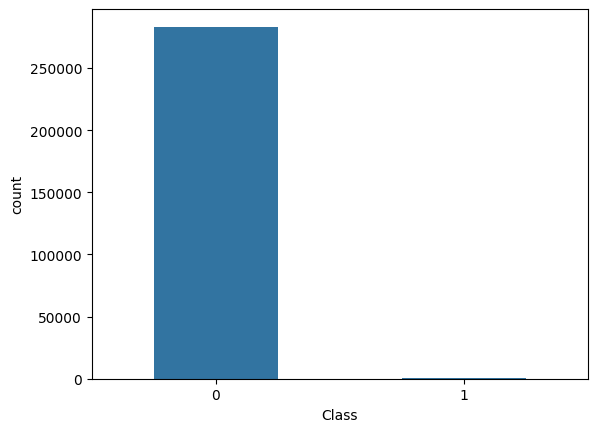

In [11]:
# PLot Of Target Feature:-
plt.figure(figsize=(10,6))
sns.countplot(x='Class',data=df,width=0.5)
plt.title('Target Feature Distribution')
plt.show()

## `Distribution And Outlier Detection:-`

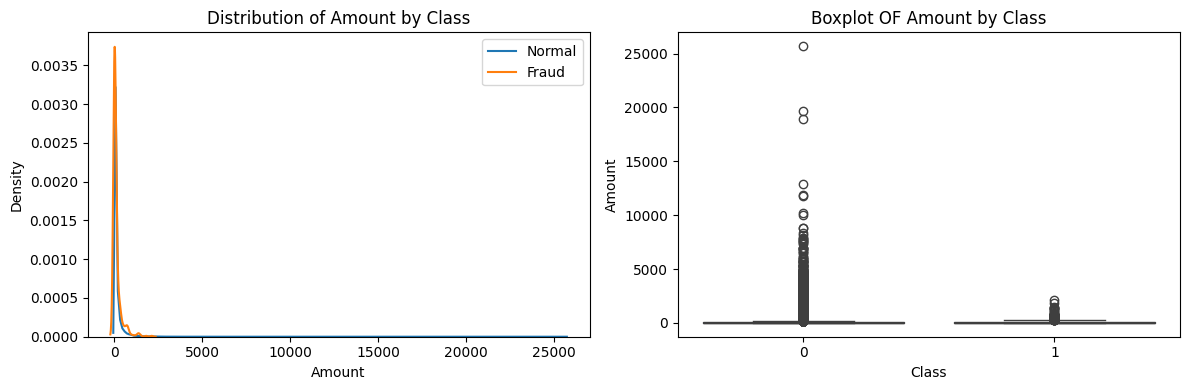

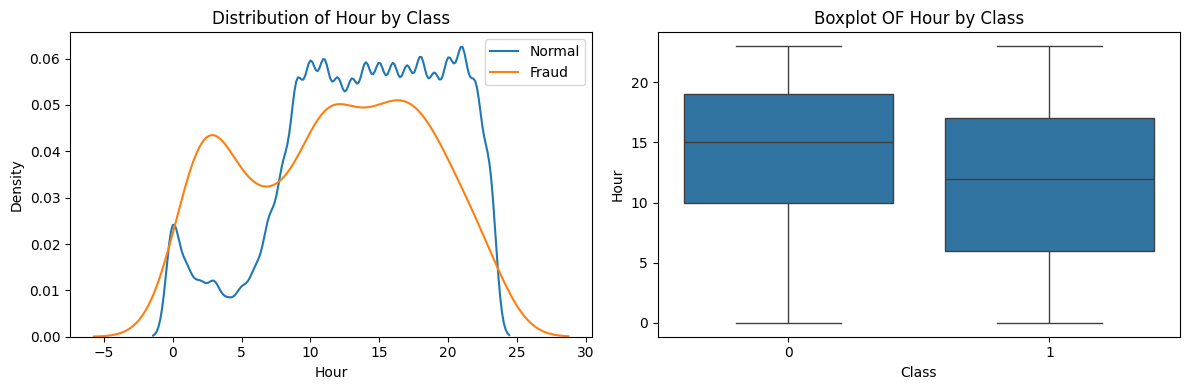

In [12]:
num_cols=['Amount','Hour']
for col in num_cols:
    fig,ax = plt.subplots(1,2,figsize=(12,4))
    # Distribution plot
    # Different for both classes.
    sns.kdeplot(df[df['Class']==0][col],label='Normal',ax=ax[0])
    sns.kdeplot(df[df['Class']==1][col],label='Fraud',ax=ax[0])
    ax[0].set_title(f'Distribution of {col} by class')
    ax[0].legend()
    ax[0].set_title(f'Distribution of {col} by Class')

    # Box plot
    sns.boxplot(data=df,x='Class',y=col ,ax=ax[1])
    ax[1].set_title(f'Boxplot OF {col} by Class')

    plt.tight_layout()
    plt.show()



*  The transaction amount feature is highly right-skewed for both classes.However, fraudulent transactions tend to occur more frequently at lower transaction amounts and exhibit a tighter distribution compared to legitimate transactions, which show a wider spread and higher extreme values.

*   Transaction time shows distinct behavioral patterns. Legitimate transactions are concentrated during daytime hours, whereas fraudulent transactions exhibit relatively higher activity during early morning hours, indicating abnormal temporal behavior.





## `Feature Wise Analysis: Important Features:-`

In [13]:
corr = df.corr()['Class'].sort_values(ascending=False)
top_features=corr.index[1:5]
print(f'Top 4 Highly Correlated Features WIth Target (Class):-\n{corr[1:5]}')

Top 4 Highly Correlated Features WIth Target (Class):-
V11    0.149067
V4     0.129326
V2     0.084624
V19    0.033631
Name: Class, dtype: float64


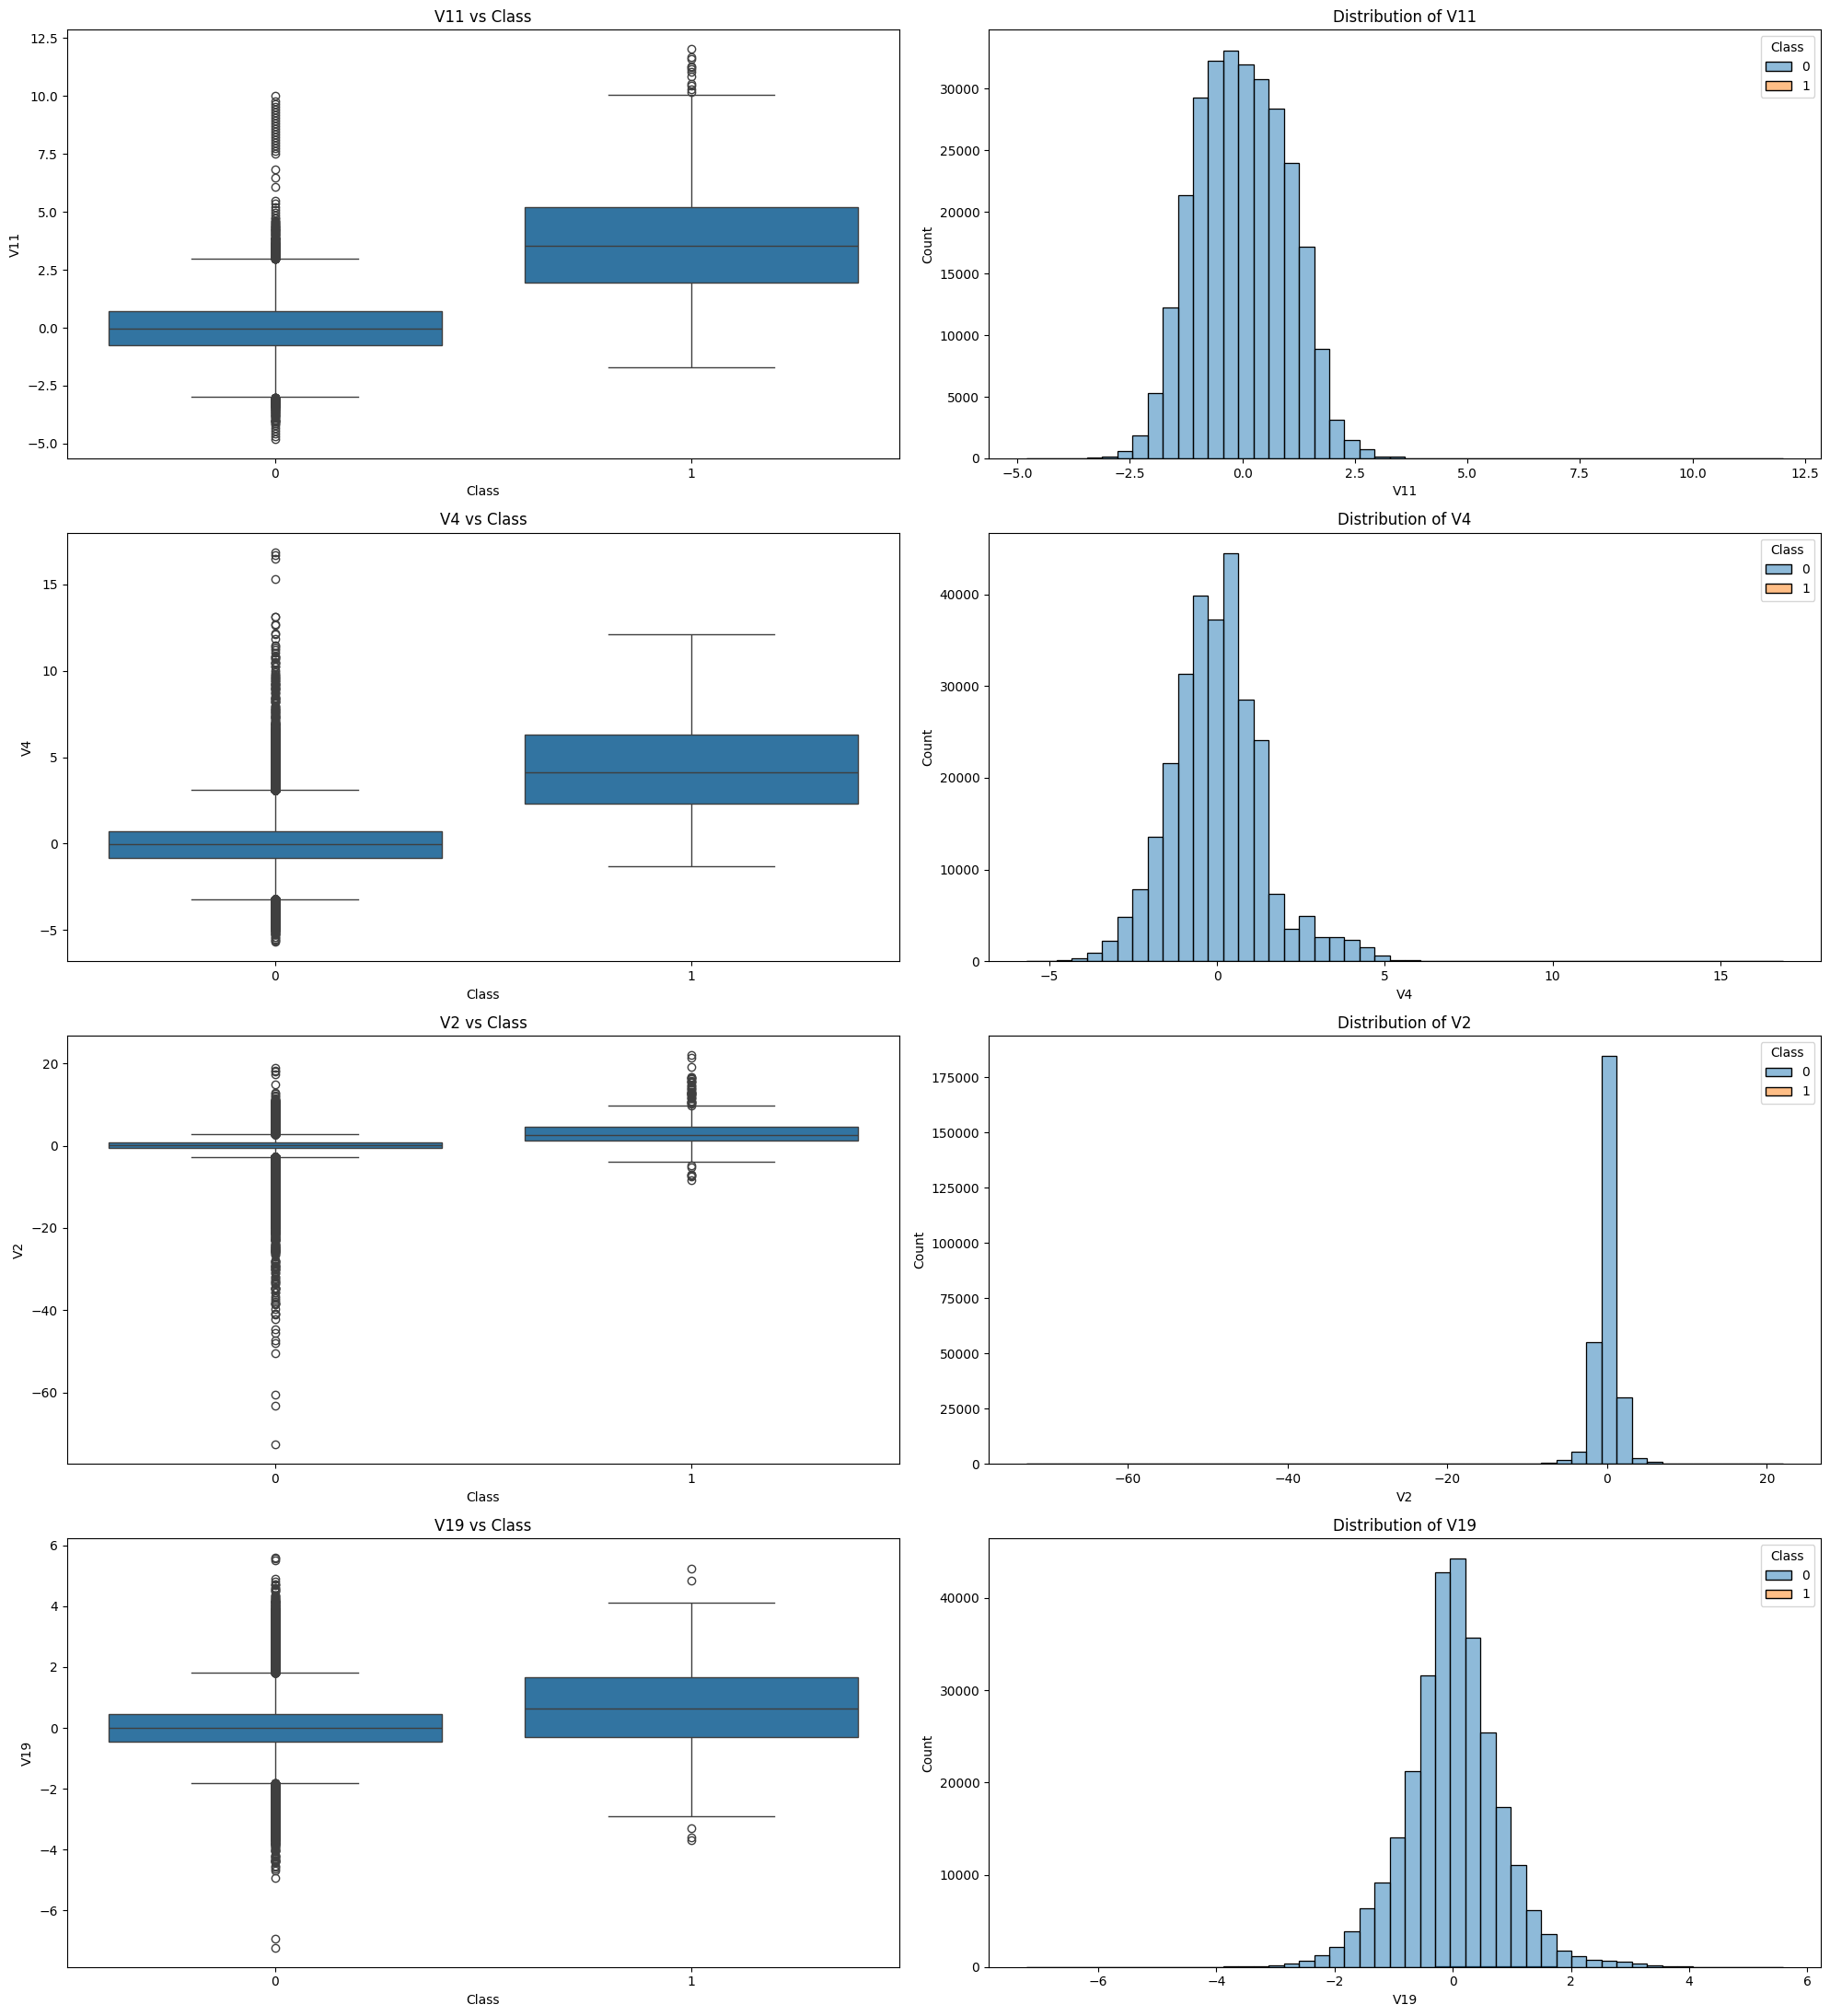

In [14]:
# Ploting the important Features:-

fig,ax = plt.subplots(nrows=len(top_features),ncols=2,figsize=(20,22))

for i, col in enumerate(top_features):

    sns.boxplot(x='Class', y=col, data=df, ax=ax[i,0])
    ax[i,0].set_title(f'{col} vs Class')

    sns.histplot(data=df, x=col, hue='Class', bins=50, ax=ax[i,1])
    ax[i,1].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

## `Correlation Heat-Map:-`

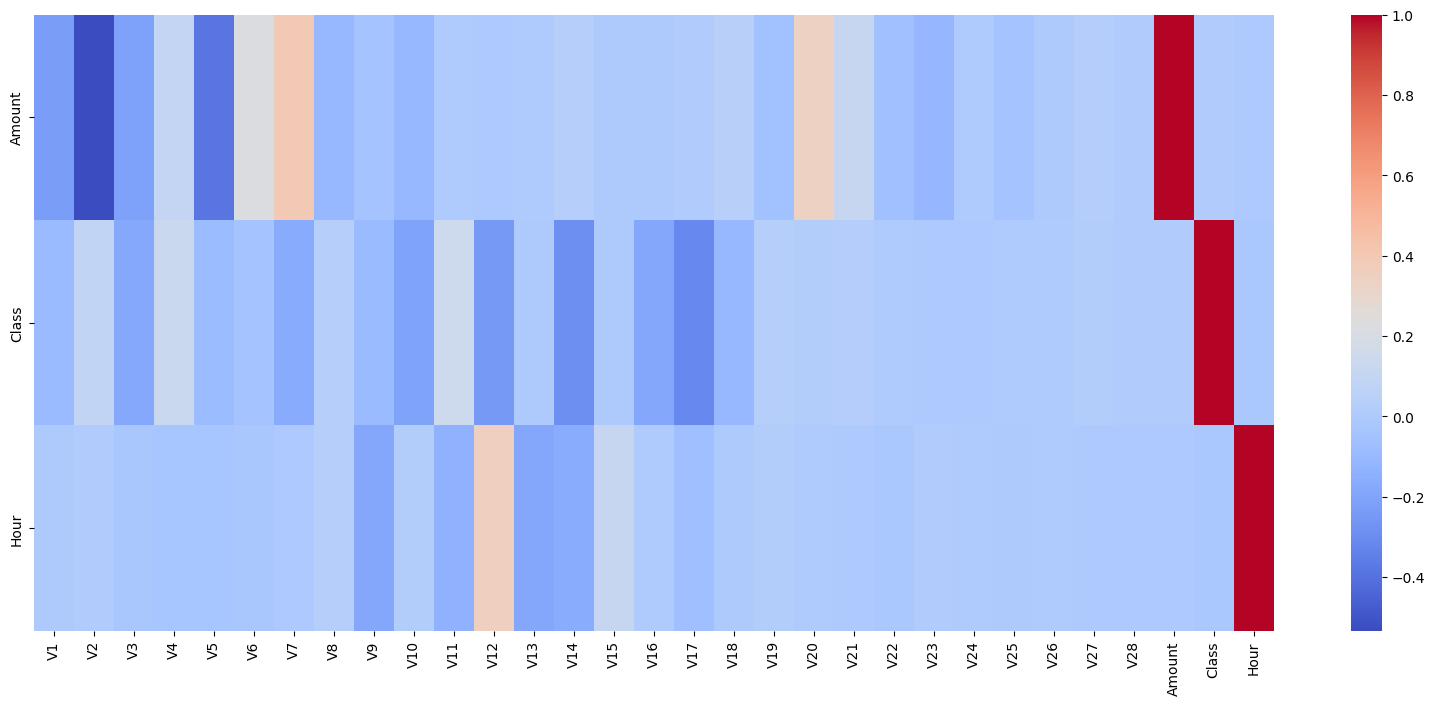

In [15]:
# No correlation Between Pca Features So Plotting only Three Features Corellation With Remaining Features:

plt.figure(figsize=(20,8))
sns.heatmap(df.corr()[28:], cmap='coolwarm')
plt.show()

# `Credit Card Fraud Detection - EDA Summary`

## 🔹 Dataset Overview
- The dataset contains ~284,000 transactions with severe class imbalance.
- Fraud transactions account for only **0.17%** of the data.

## 🔹 PCA Features (V1–V28)
- Features are transformed using PCA, making them **uncorrelated by design**.
- Individual features show **low linear correlation with the target**.
- However, several features exhibit **clear distribution differences between classes**.

## 🔹 Important Features
- Features such as **V11, V4, and V2** show strong separation between fraud and non-fraud transactions.
- Feature importance is better captured through **distribution analysis rather than correlation**.

## 🔹 Amount Feature
- The `Amount` feature is **highly right-skewed**.
- Fraud transactions are mostly **low-value transactions**.
- High-value outliers are mostly present in **normal transactions** and were retained.

## 🔹 Time / Hour Feature
- The `Time` feature was converted into `Hour` to capture daily transaction behavior.
- Fraud transactions are relatively more frequent during **early morning hours**.

## 🔹 Outlier Analysis
- Outliers were not removed as they may represent **fraudulent behavior patterns**.

## 🔹 Correlation Insights
- PCA transformation results in **low feature-to-feature correlation**.
- Low correlation with the target suggests **non-linear relationships**.

## 🔹 Overall Insight
- Fraud detection is an **anomaly detection problem**, where patterns are subtle, non-linear, and spread across multiple features.

---

# Train-Test-Split

In [16]:
X = df.drop(columns='Class')
y = df['Class']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print(f'X_train Shape:- {X_train.shape}')
print(f'X_test Shape:- {X_test.shape}')


X_train Shape:- (226980, 30)
X_test Shape:- (56746, 30)


# Model 1:- Logistic Regression

## `Pipeline:-`

In [17]:
preprocessore = ColumnTransformer([
    ('amount_log_scale',Pipeline([
        ('log',FunctionTransformer(np.log1p)),    # Amount is highly right Skewed Log applied..
        ('scale',StandardScaler())
        ]),['Amount']),
    ('hour_scale',StandardScaler(),['Hour'])],remainder='passthrough')

# Pipeline
pipeline_lr = Pipeline([('preprocessore',preprocessore),
                        ('smote',SMOTE(random_state=42)),
                        ('model_lr',LogisticRegression(max_iter=1000,class_weight='balanced'))]
)

pipeline_lr.fit(X_train,y_train)

y_prob = pipeline_lr.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.9).astype(int)



In [18]:
# Precision Recall Trade-Off      #0.9 selected for higher Precision..
for i in [0.3,0.5,0.7,0.9]:
  y_pred=(y_prob>i).astype(int)

  print(f"\nThreshold: {i}")
  print(classification_report(y_test, y_pred))


Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     56651
           1       0.02      0.87      0.05        95

    accuracy                           0.94     56746
   macro avg       0.51      0.91      0.51     56746
weighted avg       1.00      0.94      0.97     56746


Threshold: 0.5
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.98     56746


Threshold: 0.7
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56651
           1       0.10      0.87      0.18        95

    accuracy                           0.99     56746
   macro avg       0.55      0.93      0.58     56746
weighted avg       1.00   

## `Logistic Regression :- Result`



```
# Classifiaction Report at threshold 0.9:-

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.22      0.81      0.34        95

    accuracy                           0.99     56746
   macro avg       0.61      0.90      0.67     56746
weighted avg       1.00      0.99      1.00     56746


```



#### Threshold tuning significantly improved model performance by balancing precision and recall. A threshold of `0.9` was selected as it reduced false positives while maintaining a high fraud detection rate.

In [19]:
# Report At 0.9 Threshold
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.22      0.81      0.34        95

    accuracy                           0.99     56746
   macro avg       0.61      0.90      0.67     56746
weighted avg       1.00      0.99      1.00     56746



# Model 2(A):- Random Forest

In [28]:
rf = RandomForestClassifier(n_estimators=200,
                                       max_depth=10,
                                       class_weight='balanced',
                                       min_samples_split=5,
                                       random_state=42,
                                       n_jobs=-1)
rf.fit(X_train,y_train)
y_pred_=rf.predict(X_test)
print(classification_report(y_test, y_pred_))



              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.89      0.74      0.80        95

    accuracy                           1.00     56746
   macro avg       0.94      0.87      0.90     56746
weighted avg       1.00      1.00      1.00     56746



## `Random Forest Results:-`


```
               precision    recall  f1-score   support

            0       1.00      1.00      1.00     56651
            1       0.89      0.74      0.80        95

     accuracy                           1.00     56746
    macro avg       0.94      0.87      0.90     56746
 weighted avg       1.00      1.00      1.00     56746
```


#### The model performs well with high precision and good recall, indicating it is reliable in detecting fraud while minimizing false alarms.

# Model 2(B):- Random-Forest + Smote

In [ ]:
pipeline_rf_sm = Pipeline([
    ('smote',SMOTE(random_state=42)),
    ('model_rf',RandomForestClassifier(n_estimators=200,
                                       max_depth=10,
                                       class_weight='balanced',
                                       min_samples_split=5,
                                       random_state=42,
                                       n_jobs=-1))
])

pipeline_rf_sm.fit(X_train,y_train)

In [ ]:
y_pred_rf=pipeline_rf_sm.predict(X_test)
print(f'Random Forest + SMOTE Result:-\n\n{classification_report(y_test, y_pred_rf)}')


## `RF + Smote Result:-`



```
 Random Forest + SMOTE Result:-

               precision    recall  f1-score   support

            0       1.00      1.00      1.00     56651
            1       0.58      0.82      0.68        95

     accuracy                           1.00     56746
    macro avg       0.79      0.91      0.84     56746
 weighted avg       1.00      1.00      1.00     56746
```


#### Random Forest with SMOTE improves fraud detection by increasing recall, but introduces more false positives, making it suitable when detecting maximum fraud is the priority.

# Model 2(C):- Random-Forest-Best-Tunned

In [21]:
pipeline_rf=Pipeline([
    ('model',RandomForestClassifier(random_state=42,n_jobs=-1))
])
# Hyper Parameter Tunning :-
param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [6, 10, 12, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2'],
    'model__class_weight': ['balanced', 'balanced_subsample']
}

# RandomSearch CV

from sklearn.model_selection import RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=pipeline_rf,
                                   param_distributions=param_dist,
                                   n_iter=20,
                                   scoring='f1',
                                   cv=3,
                                   verbose=2,
                                   random_state=42,
                                   n_jobs=-1)

random_search.fit(X_train, y_train)

# best Rf Model
best_rf_pipeline = random_search.best_estimator_

# Predict
y_pred_rf = best_rf_pipeline.predict(X_test)

print(classification_report(y_test, y_pred_rf))



Fitting 3 folds for each of 20 candidates, totalling 60 fits
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.98      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746



##` Tunned Random Forest Classification Report:-`

```
Fitting 3 folds for each of 20 candidates, totalling 60 fits

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.98      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746

```

## `Tuned Random-Forest Result:-`
#### The tuned Random Forest model performed the best, achieving high precision and a strong F1-score. It provided a good balance between detecting fraud and minimizing false positives, which is critical in fraud detection systems.

## `Tunned Random Forest Best Features:-`

In [25]:
rf_best_model = best_rf_pipeline.named_steps['model']
importance = rf_best_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Features':X_train.columns,
    'Importance':importance})

feature_importance_df = feature_importance_df.sort_values(by= 'Importance', ascending=False)

feature_importance_df.head(10)

,Features,Importance
13,V14,0.161271
9,V10,0.130833
3,V4,0.117921
16,V17,0.095131
11,V12,0.075494
2,V3,0.075343
10,V11,0.054302
6,V7,0.035217
15,V16,0.033972
20,V21,0.019135


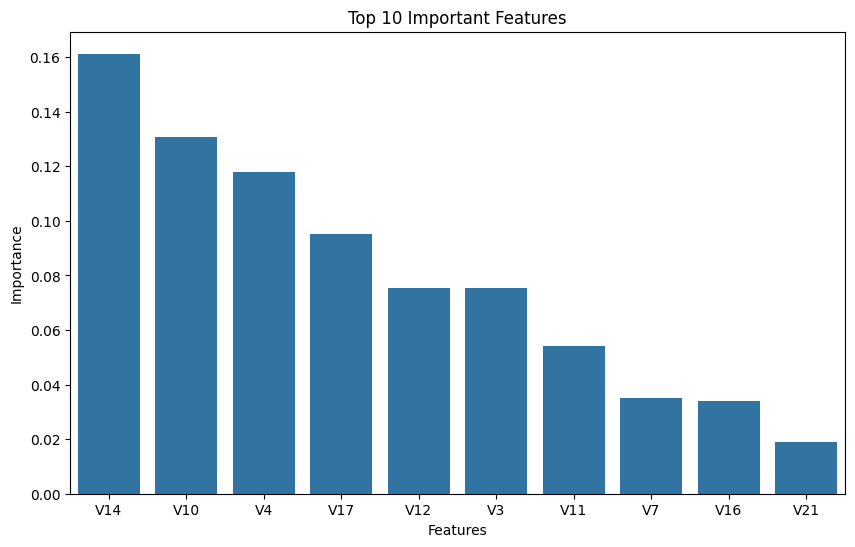

In [27]:
# Plot Best Features RF..
top_features = feature_importance_df.head(10)
plt.figure(figsize=(10,6))
sns.barplot(x='Features',y='Importance',data=top_features)
plt.title('Top 10 Important Features')
plt.show()




```
Features Importance
V14	      0.161271
V10	      0.130833
V4	      0.117921
V17	      0.095131
V12	      0.075494
V3	      0.075343
V11       0.054302
V7	      0.035217
V16	      0.033972
V21	      0.019135
```








### Even though correlation with target was low, feature importance reveals that certain PCA components play a significant role in detecting fraud, indicating non-linear relationships in the data.

### A small subset of PCA features drives most of the fraud detection capability, highlighting the importance of hidden patterns rather than individual raw features.


 ### The tuned Random Forest model provided the best balance between precision and recall, making it highly effective for fraud detection. The project demonstrates the importance of handling class imbalance, understanding model trade-offs, and leveraging ensemble methods for complex classification problems.

# Model 3:- XG-Boost

In [30]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(f'Scale Positive Weight:- {scale_pos_weight}')

Scale Positive Weight:- 599.4761904761905


In [31]:
# XGB Pipeline:-

pipeline_xgb = Pipeline([
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,      #Pay extra attention to rare fraud cases
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    ))
])

In [32]:
# Fit XGB..
pipeline_xgb.fit(X_train, y_train)

Pipeline(steps=[('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [47]:
y_prob_xgb = pipeline_xgb.predict_proba(X_test)[:,1]
y_pred_xgb = (y_prob_xgb > 0.4).astype(int)

In [48]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.95      0.80      0.87        95

    accuracy                           1.00     56746
   macro avg       0.97      0.90      0.93     56746
weighted avg       1.00      1.00      1.00     56746



## `XGB Results:-`

#### The model achieves high precision while improving recall, meaning it detects more fraud cases without significantly increasing false alarms.



```
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.95      0.80      0.87        95

    accuracy                           1.00     56746
   macro avg       0.97      0.90      0.93     56746
weighted avg       1.00      1.00      1.00     56746

```




In [51]:
xgb_model = pipeline_xgb.named_steps['model']
xgb_importance = xgb_model.feature_importances_

xgb_feature_importance_df = pd.DataFrame({
    'Features':X_train.columns,
    'Importance':xgb_importance})

xgb_feature_importance_df = xgb_feature_importance_df.sort_values(by= 'Importance', ascending=False)

xgb_feature_importance_df.head(10)

,Features,Importance
13,V14,0.452102
9,V10,0.114771
3,V4,0.070511
11,V12,0.038511
7,V8,0.027839
18,V19,0.021575
19,V20,0.021063
2,V3,0.019115
10,V11,0.017255
12,V13,0.017118


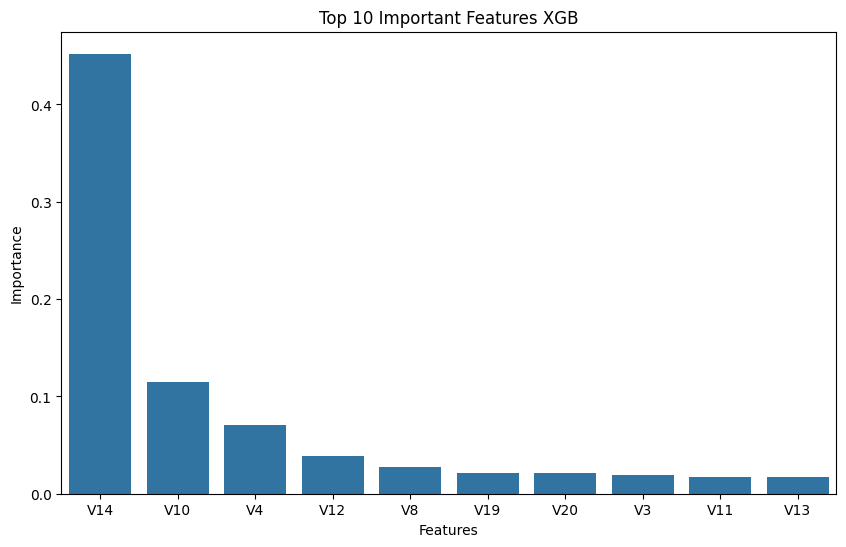

In [53]:
# Plot Xgb Best Features..
top_features_xgb = xgb_feature_importance_df.head(10)
plt.figure(figsize=(10,6))
sns.barplot(x='Features',y='Importance',data=top_features_xgb)
plt.title('Top 10 Important Features XGB')
plt.show()

## `Comparison of Both Rf And XGB Best Features :-`

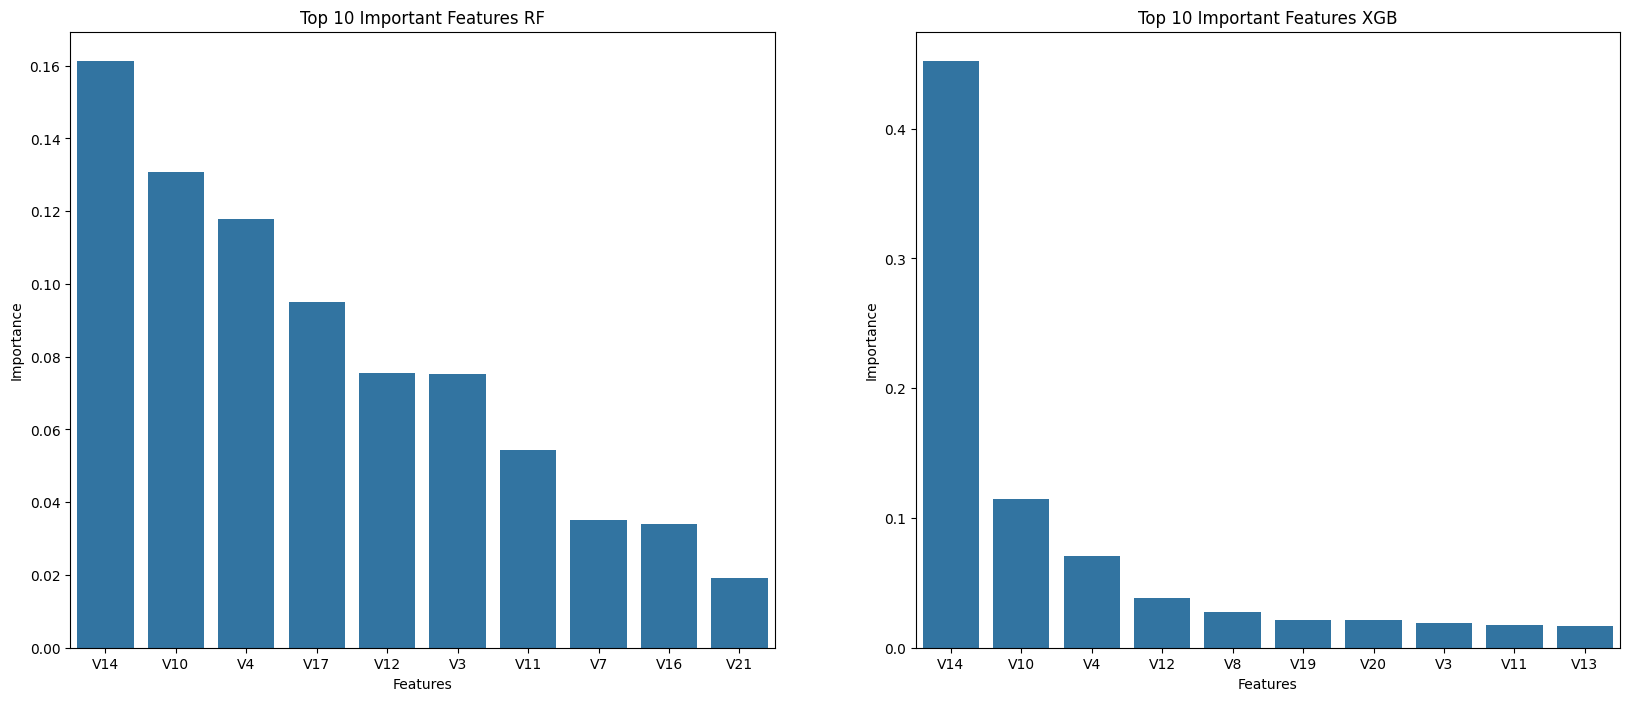

In [55]:
# SIde by Side comparision of Feature Importance RF v/s XGB:-

top_features_rf = feature_importance_df.head(10)
top_features_xgb = xgb_feature_importance_df.head(10)

fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(20,8))
# Rf
sns.barplot(x='Features',y='Importance',data=top_features_rf,ax=ax[0])
ax[0].set_title('Top 10 Important Features RF')
#Xgb
sns.barplot(x='Features',y='Importance',data=top_features_xgb)
ax[1].set_title('Top 10 Important Features XGB')
plt.show()

# **`Conclusion`:-**
### XGBoost performed the best, achieving a high precision of 95% and improving recall to 80%, resulting in the highest F1-score. It provided the best balance between detecting fraud and minimizing false positives.

### Both Random Forest and XGBoost identified similar top features such as V14, V10, and V4, indicating strong underlying patterns for fraud detection. XGBoost showed a more concentrated reliance on key features, while Random Forest distributed importance across multiple features.

### XGBoost provided the best overall performance by balancing high precision with improved recall, making it the most suitable model for fraud detection in this project.